# Independent references and physical limits

This notebook distinguishes predictive property comparisons against an independent reference EOS from conservation-law and search-algorithm verification. Expected NIST states are archived separately from NeqSim outputs. The declared tolerances in `benchmark_design.json` predate the first actual comparisons. No case-specific field calibration is claimed.


In [1]:
import os, sys, subprocess, json
from pathlib import Path
ROOT = Path(globals().get('__file__', '36_benchmark_validation.ipynb')).resolve().parent
assert os.environ.get('NEQSIM_PROJECT_ROOT'), 'Select the compiled NeqSim source explicitly'
completed = subprocess.run([sys.executable, str(ROOT/'run_independent_benchmarks.py')],
                           capture_output=True, text=True, env=os.environ.copy())
print(completed.stdout)
if completed.stderr: print(completed.stderr)
completed.check_returncode()
results = json.loads((ROOT/'benchmark_results.json').read_text(encoding='utf-8'))
assert results['status'] == 'passed' and not results['failures']
print('Source revision:', results['source_revision'])
print('Interpreter:', results['python'])
print('Passed comparisons:', len(results['comparisons']))


NIST methane done
ideal dilute gas done
Rachford-Rice done
flash equilibrium done
throttling valves done
ideal compressor done
hydraulic limits done
separator done
optimizer done
BENCHMARKS 89 comparisons; 0 failures

Source revision: 6cc8026202a5d3f9383c9abd1d97d448993813f9
Interpreter: C:\Users\solbraa\.cache\codex-runtimes\codex-primary-runtime\dependencies\python\python.exe
Passed comparisons: 89


The property comparison covers nine methane states at 300, 350 and 400 K and 1, 50 and 100 bara with both SRK and PR. These NIST WebBook values are reference-equation calculations, not raw experimental observations. Their use checks selected cubic-EOS predictions against an independent thermodynamic model.


EOS | T (K) | P (bara) | NIST density (kg/m3) | NeqSim density (kg/m3) | deviation (%)
SRK | 300 | 1 | 0.64425426 | 0.64426385 | +0.00149
SRK | 350 | 1 | 0.55178767 | 0.5517698 | -0.00324
SRK | 400 | 1 | 0.48259833 | 0.48257205 | -0.00545
SRK | 300 | 50 | 34.971714 | 34.858308 | -0.32428
SRK | 350 | 50 | 28.74284 | 28.620764 | -0.42472
SRK | 400 | 50 | 24.597747 | 24.487188 | -0.44947
SRK | 300 | 100 | 75.175486 | 74.107423 | -1.42076
SRK | 350 | 100 | 59.261246 | 58.574033 | -1.15963
SRK | 400 | 100 | 49.735904 | 49.229374 | -1.01844
PR  | 300 | 1 | 0.64425426 | 0.6444431 | +0.02931
PR  | 350 | 1 | 0.55178767 | 0.55189111 | +0.01875
PR  | 400 | 1 | 0.48259833 | 0.48265674 | +0.01210
PR  | 300 | 50 | 34.971714 | 35.255414 | +0.81123
PR  | 350 | 50 | 28.74284 | 28.874387 | +0.45767
PR  | 400 | 50 | 24.597747 | 24.659788 | +0.25222
PR  | 300 | 100 | 75.175486 | 75.263312 | +0.11683
PR  | 350 | 100 | 59.261246 | 59.332068 | +0.11951
PR  | 400 | 100 | 49.735904 | 49.752842 | +0.03406


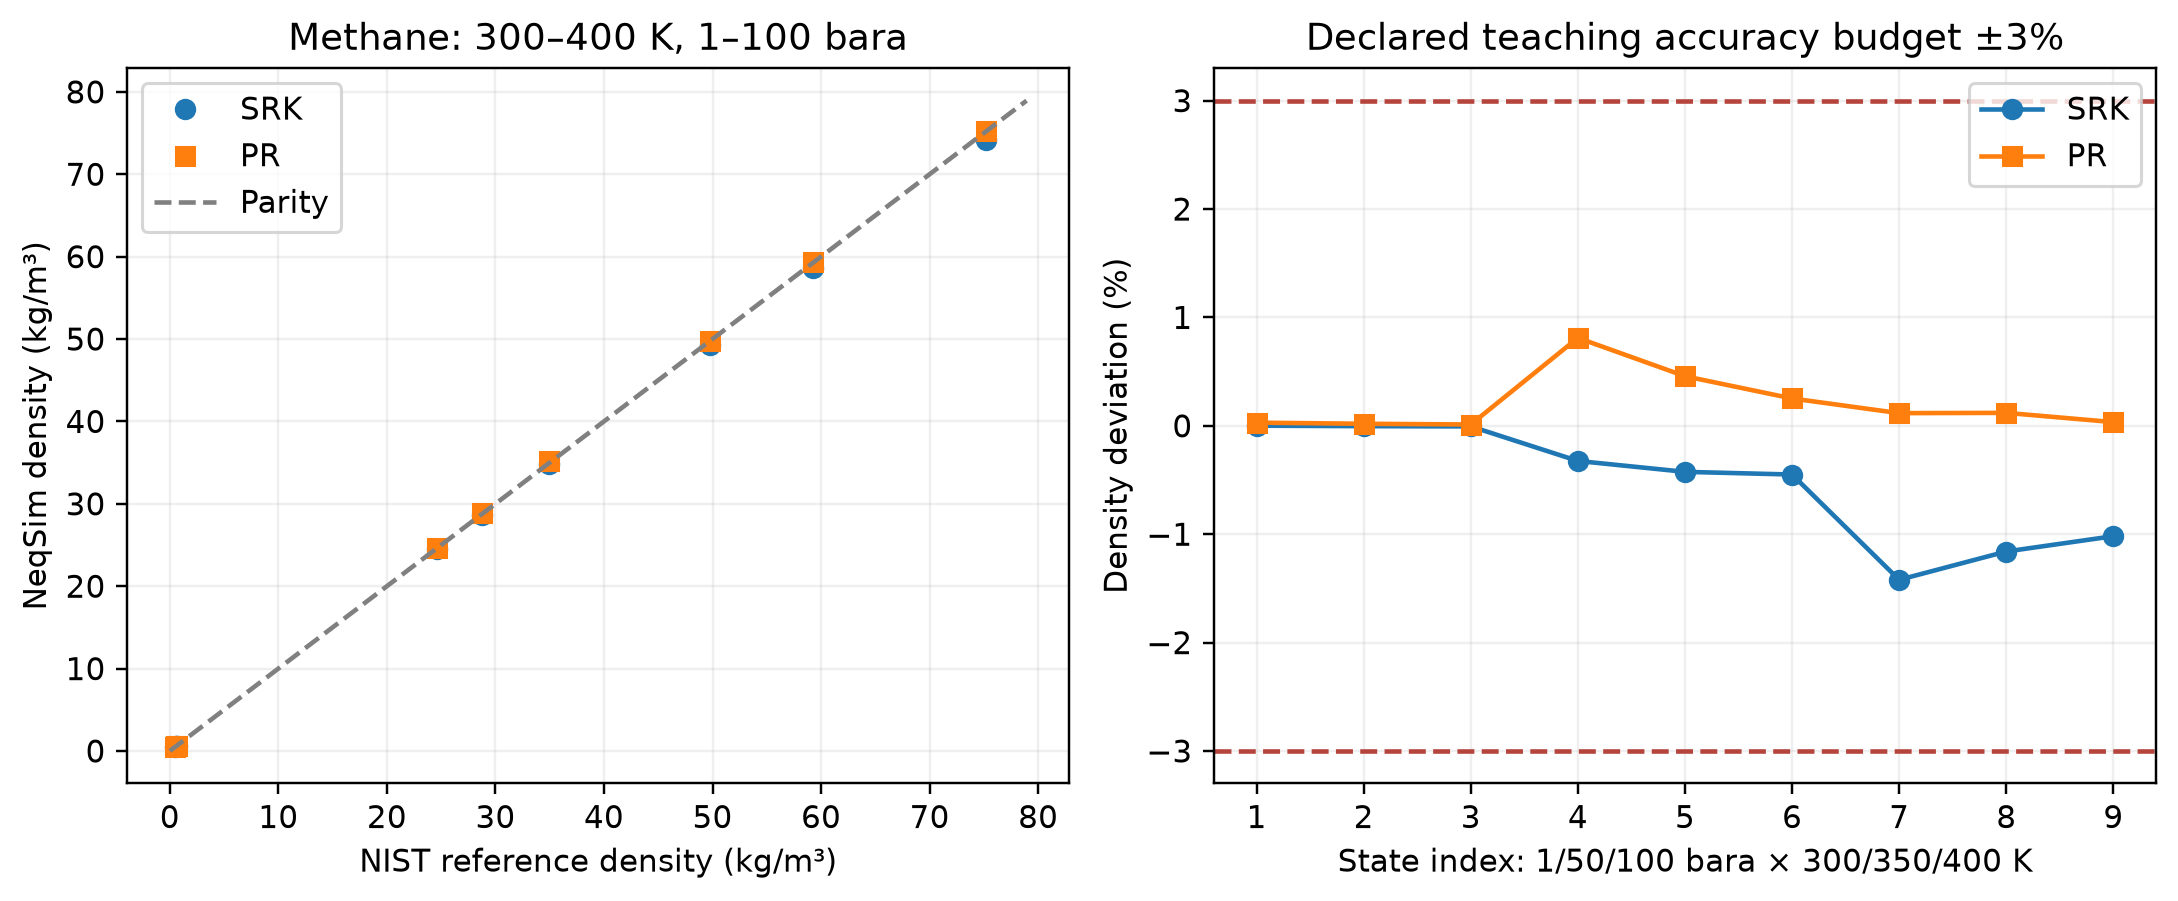

In [2]:
print('EOS | T (K) | P (bara) | NIST density (kg/m3) | NeqSim density (kg/m3) | deviation (%)')
for row in results['comparisons']:
    if row['name'] in ('SRK methane density', 'PR methane density'):
        state = row['case']
        deviation = 100*(row['actual']/row['expected']-1)
        print(f"{row['name'][:3]} | {state['T_K']:.0f} | {state['P_bara']:.0f} | {row['expected']:.8g} | {row['actual']:.8g} | {deviation:+.5f}")
FIGURE = ROOT/'figures/nist_methane_density_validation.png'
assert FIGURE.exists()


The parity and deviation plot tests the stated ±3% teaching accuracy budget. Higher-pressure deviations reflect the approximate attraction and excluded-volume descriptions in cubic EOS. Passing this grid supports these methane states only; mixture phase envelopes, water association and near-critical derivatives require their own reference data. Use measured composition and applicable laboratory data before extending the model to a field fluid.


In [3]:
from collections import defaultdict
groups = defaultdict(list)
for row in results['comparisons']: groups[row['evidence_type']].append(row)
print('Evidence class | comparisons | passed')
for name, rows in groups.items(): print(name, '|', len(rows), '|', sum(r['passed'] for r in rows))
for row in results['comparisons']:
    if 'optimizer' in row['name'] or 'hydrostatic' in row['name'] or 'argon' in row['name']:
        print(row['name'], ':', row['actual'], row['unit'], '; expected', row['expected'],
              '; absolute acceptance bound', row['acceptance_bound_absolute'])


Evidence class | comparisons | passed
independent reference EOS | 18 | 18
independent analytical limit | 10 | 10
independent analytical solution | 3 | 3
conservation and equilibrium verification | 34 | 34
conservation-law verification | 18 | 18
analytical momentum limit | 3 | 3
independent search algorithm verification | 1 | 1
constraint verification | 1 | 1
analytical scaling verification | 1 | 1
ideal monatomic argon compressor outlet temperature : 366.02088085949913 K ; expected 366.02963344675254 ; absolute acceptance bound 0.7320592668935051
ideal monatomic argon compressor shaft power : 9.543590233625508 kW ; expected 9.543672729120512 ; absolute acceptance bound 0.019087345458241024
ideal monatomic argon compressor outlet temperature : 419.7923602603061 K ; expected 419.8154665398353 ; absolute acceptance bound 0.8396309330796706
ideal monatomic argon compressor shaft power : 17.317365542987737 kW ; expected 17.317673003064595 ; absolute acceptance bound 0.03463534600612919
idea

The ideal-gas and monatomic-argon compressor cases use analytical limits independent of NeqSim. Hydrostatics tests the momentum equation using a specified input density, so it does not independently validate liquid density. Flash fugacity equality, stream material balance and the first law verify internal consistency. The optimizer is checked by direct enumeration in a fresh process; its thermodynamics still use the same EOS.

Primary sources and retrieved originals are indexed in [the reference archive](references/SOURCES.md). No external hydrate, inhibited-solvent, vendor-map, field-flow, transient-control or economic dataset is included; those predictions remain outside this benchmark’s accuracy claim.
